In [2]:
# Install required libraries
!pip install torch torchvision matplotlib

# Import libraries
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pretrained model
model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(4096, 2)  # (Binary classification: aneurysm / non-aneurysm)
model = model.to(device)

# 🔥 Fix the ReLU inplace problem for GradCAM
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

model.eval()

# Define GradCAM
gradients = []
activations = []

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.append(output)

def generate_gradcam(model, input_tensor, original_image):
    # Reset
    gradients.clear()
    activations.clear()

    # Register hooks to the last conv layer
    final_conv = None
    for name, module in model.features._modules.items():
        if isinstance(module, nn.Conv2d):
            final_conv = module

    if final_conv is not None:
        final_conv.register_forward_hook(save_activation)
        final_conv.register_backward_hook(save_gradient)
    else:
        raise Exception("No convolution layer found!")

    # Forward pass
    output = model(input_tensor)
    pred_class = output.argmax(dim=1)

    # Zero grads
    model.zero_grad()

    # Backward pass for the predicted class
    class_loss = output[0, pred_class]
    class_loss.backward()

    # Get hooked gradients and activations
    grads_val = gradients[0].cpu().data.numpy()[0]
    activations_val = activations[0].cpu().data.numpy()[0]

    # Global Average Pooling
    weights = np.mean(grads_val, axis=(1, 2))
    cam = np.zeros(activations_val.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * activations_val[i, :, :]

    # Relu + Normalize
    cam = np.maximum(cam, 0)
    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)
    cam = np.uint8(cam * 255)

    # Resize cam to original image
    cam = Image.fromarray(cam).resize(original_image.size, Image.BILINEAR)
    cam = np.array(cam)

    return cam, pred_class.item()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:05<00:00, 110MB/s]


In [4]:
# Function to overlay GradCAM heatmap on original image
def overlay_heatmap(img, cam, alpha=0.5, colormap=plt.cm.jet):
    heatmap = colormap(cam / 255.0)[:, :, :3]  # RGB heatmap
    heatmap = np.uint8(heatmap * 255)

    superimposed_img = np.array(img) * (1 - alpha) + heatmap * alpha
    superimposed_img = np.uint8(superimposed_img)

    return superimposed_img

Saving brainscan.jpeg to brainscan.jpeg

🧠 Prediction: Aneurysm


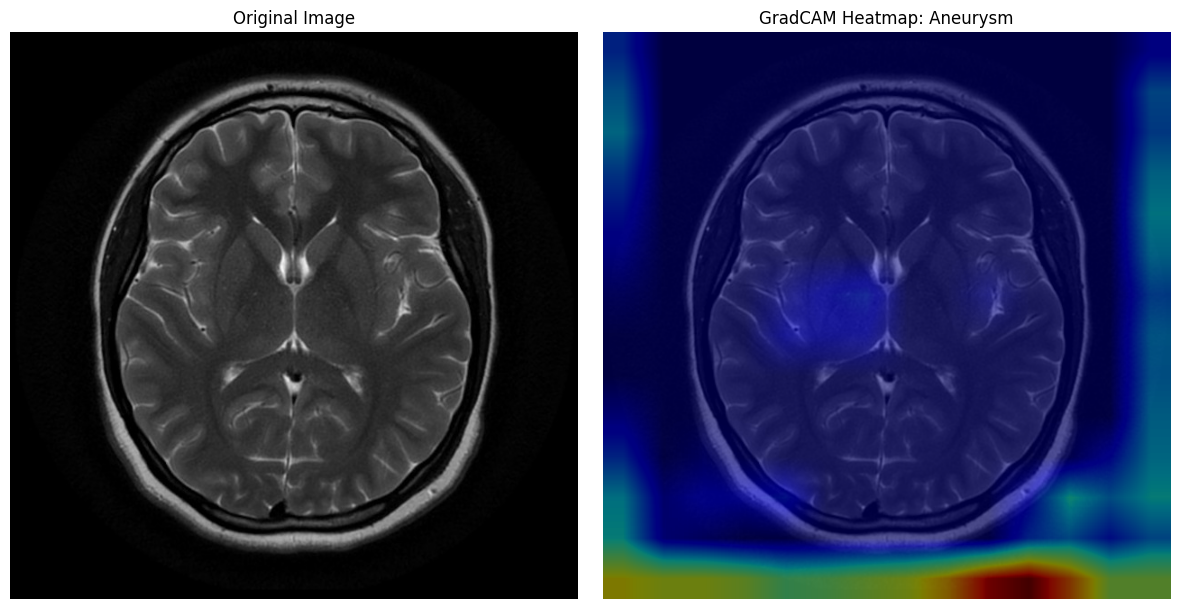

In [6]:
# Upload your image
from google.colab import files
uploaded = files.upload()

# Load uploaded image
for filename in uploaded.keys():
    img_path = filename

# Preprocess the image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

original_image = Image.open(img_path).convert('RGB')
input_tensor = transform(original_image).unsqueeze(0).to(device)

# Predict the class (0 or 1)
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
class_name = "Aneurysm" if pred_class == 1 else "Non-aneurysm"
print(f"\n🧠 Prediction: {class_name}")

# Generate GradCAM for the predicted class
cam, _ = generate_gradcam(model, input_tensor, original_image)

# Overlay heatmap
superimposed_img = overlay_heatmap(original_image, cam)

# Plot results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"GradCAM Heatmap: {class_name}")
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()